In [107]:
from collections import defaultdict
from AzgaarFunctions import *
import pandas
import json
BASE_DEMAND = {
    "food": 2.5,
    "stone": 0.5,
    "gold": 0.26,
}

def calculate_demand_state(self):
    out = {}
    for s in self.states:
        state_demand = {}
        for resource in RESOURCES:
            pop = s.get("rural", 0) + s.get("urban", 0)
            state_demand[resource] = pop * BASE_DEMAND[resource]
        out[s["name"]] = state_demand
    return out
class ViliaEconomy():
    def __init__(self, fmg_json):
        pack         = fmg_json["pack"]
        self.routes  = pack["routes"]
        self.biomes  = fmg_json["biomesData"]
        self.states  = [s for s in pack["states"]    if isinstance(s, dict)]
        self.provinces = [p for p in pack["provinces"] if isinstance(p, dict)]
        self.cells   = [c for c in pack["cells"]     if isinstance(c, dict)]

        self.year = fmg_json.get("settings", {}).get("options", {}).get("year", 1)
      

def load_from_file(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return ViliaEconomy(data)

data = load_from_file("ViliaFull.json")


print(calculate_demand_state(data))

{'Neutrals': {'food': 1116.4794965088367, 'stone': 223.29589930176735, 'gold': 116.11386763691903}, 'Monch': {'food': 1511.0230067491532, 'stone': 302.2046013498306, 'gold': 157.14639270191194}, 'Bacseslamia': {'food': 14733.815490567087, 'stone': 2946.7630981134175, 'gold': 1532.3168110189772}, 'Kouria': {'food': 40507.66849586427, 'stone': 8101.5336991728545, 'gold': 4212.797523569884}, 'Memein': {'food': 10650.868763991593, 'stone': 2130.1737527983187, 'gold': 1107.6903514551257}, 'Ingne': {'food': 13760.343247083427, 'stone': 2752.0686494166853, 'gold': 1431.0756976966763}, 'Ardonia': {'food': 7249.510737904907, 'stone': 1449.9021475809814, 'gold': 753.9491167421104}, 'Loshin': {'food': 43338.39652172864, 'stone': 8667.679304345727, 'gold': 4507.193238259779}, 'Degyesia': {'food': 20736.424028713704, 'stone': 4147.284805742741, 'gold': 2156.5880989862253}, 'Anaia': {'food': 31263.454492790697, 'stone': 6252.690898558139, 'gold': 3251.3992672502327}, 'Ogskifta': {'food': 10880.33373

In [108]:

calculate_cell_reserve(data)
print("Total stone max:", sum(c["stone_max"] for c in data.cells))
print("stone Reserve:", sum(c["stone_reserve"] for c in data.cells))
print("Total gold max:", sum(c["gold_max"] for c in data.cells))
print("gold Reserve:", sum(c["gold_reserve"] for c in data.cells))



Total stone max: 45623.3965183501
stone Reserve: 456233.96518350096
Total gold max: 22318.90950459942
gold Reserve: 223189.0950459942


In [109]:

print(tick(data))
print(calculate_demand_state(data))



{'Neutrals': {'food': 373.2485845232009, 'stone': 64.43628807663917, 'gold': 31.001820036768912}, 'Monch': {'food': 654.4711554813383, 'stone': 156.44904204368584, 'gold': 76.33596051216124}, 'Bacseslamia': {'food': 7249.494476523395, 'stone': 663.707453635931, 'gold': 331.477784821391}, 'Kouria': {'food': 19337.44332794192, 'stone': 3991.057343716628, 'gold': 1939.7862523472336}, 'Memein': {'food': 4981.6098310554025, 'stone': 1337.6276315712942, 'gold': 656.344068765044}, 'Ingne': {'food': 6707.611832284923, 'stone': 1132.1011217415332, 'gold': 546.17720287621}, 'Ardonia': {'food': 3870.7875650924434, 'stone': 754.2777004754538, 'gold': 373.1724197575449}, 'Loshin': {'food': 20256.496756878685, 'stone': 4608.582587457596, 'gold': 2260.8315666830517}, 'Degyesia': {'food': 10530.922603585715, 'stone': 1352.37839101553, 'gold': 656.8351879727841}, 'Anaia': {'food': 15093.39989011526, 'stone': 2981.247750004529, 'gold': 1434.2660560053575}, 'Ogskifta': {'food': 5523.474478221552, 'stone'

In [110]:

print("Total stone max:", sum(c["stone_max"] for c in data.cells))
print("Stone Reserve:", sum(c["stone_reserve"] for c in data.cells))
print("Total gold max:", sum(c["gold_max"] for c in data.cells))
print("Gold Reserve:", sum(c["gold_reserve"] for c in data.cells))


Total stone max: 45623.3965183501
Stone Reserve: 410610.56866515084
Total gold max: 22318.90950459942
Gold Reserve: 200870.1855413948


In [111]:
#figure out the trade betweent burgs and their nearest city

from collections import defaultdict
graph = defaultdict(list)
def calculate_nearest_city(graph, cells):



    # 1. Normal neighbor connections
    for cell in data.cells:
        cid = cell["i"]
        for n in cell["c"]:
            graph[cid].append((n, 1.0))  # base cost

    for route in data.routes:
        group = route.get("group")

        # assign cost by type
        if group == "roads":
            road_cost = 0.3
        elif group == "trails":
            road_cost = 0.6
        else:
            road_cost = 1.0

        points = route["points"]

        for i in range(len(points) - 1):
            c1 = points[i][2]
            c2 = points[i+1][2]

            graph[c1].append((c2, road_cost))
            graph[c2].append((c1, road_cost))

    import heapq

    def compute_nearest_city(graph, cells):
        pq = []
        dist = {}
        parent = {}
        nearest_city = {}

        # initialize with all cities
        for cell in cells:
            if cell.get("burg", 0) != 0:
                cid = cell["i"]
                dist[cid] = 0
                nearest_city[cid] = cid
                parent[cid] = None
                heapq.heappush(pq, (0, cid))

        # expand outward
        while pq:
            cost, current = heapq.heappop(pq)

            for neighbor, edge_cost in graph[current]:
                new_cost = cost + edge_cost

                if neighbor not in dist or new_cost < dist[neighbor]:
                    dist[neighbor] = new_cost
                    parent[neighbor] = current
                    nearest_city[neighbor] = nearest_city[current]
                    heapq.heappush(pq, (new_cost, neighbor))

        return dist, parent, nearest_city

    def get_path(cell_id, parent):
        path = []
        while cell_id is not None:
            path.append(cell_id)
            cell_id = parent[cell_id]
        return path[::-1]

    dist, parent, nearest_city = compute_nearest_city(graph, data.cells)
    return nearest_city, dist, parent


In [112]:

def calculate_demand_cell(self):
    out = {}
    for c in self.cells:
        cell_id = c["i"]
        if c.get("pop", 0) > 0:
            out[cell_id] = {}
            for resource in RESOURCES:
                out[cell_id][resource] = c["pop"] * BASE_DEMAND[resource]
        else:
            out[cell_id] = {resource: 0 for resource in RESOURCES}

    return out

print(calculate_demand_cell(data)[0])


# now that we have the nearest city for each cell, we can calculate the surplus/deficit for each cell and see how much trade is needed to reach balance
cell_demand = calculate_demand_cell(data)



{'food': 0, 'stone': 0, 'gold': 0}


In [113]:

def tick(self):
    # food production is based on the biome, with a bonus for being near a river or coast, and a penalty for being at high elevation
    def calculate_food_production_state():
        cell_production = {}  # state_id -> total food
        for c in self.cells:
            if c.get("h", 0) > 20:  # Only cells with elevation above 20 can produce
                biome_id = c["biome"]
                grain_yield = GRAIN_BIOME.get(biome_id, 0)
                # Bonus for being near a river or coast
                if c.get("river", False):
                    grain_yield *= 1.2
                if c.get("coast", False):
                    grain_yield *= 1.1
                if c.get("pop", 0) > 0:
                    grain_yield *= 1 + (c["pop"] / 1)  # Bonus for population

                grain_yield = grain_yield - c.get("height", 0) * 0.01  # Penalty for height
                # FIX: accumulate per state_id instead of overwriting
                state_id = c["state"]
                cell_production[state_id] = cell_production.get(state_id, 0) + grain_yield

        # Roll up cell totals to state names
        out = {}
        for state in self.states:
            state_id = state["i"]
            out[state["name"]] = {"food": cell_production.get(state_id, 0)}
        return out
    
    def calculate_stone_production_state():
        cell_production = {}  # state_id -> total stone
        for c in self.cells:
            if c.get("h", 0) > 20:  # Only cells with elevation above 120 can produce
                biome_id = c["biome"]
                stone_yield = STONE_BIOME.get(biome_id, 0)
                # Bonus for being near a river or coast
                if c.get("river", False):
                    stone_yield *= 1.2
                if c.get("coast", False):
                    stone_yield *= 0.8
                if c.get("pop", 0) > 0:
                    stone_yield *= 1 + (c["pop"] / 1)  # Bonus for population

                stone_yield *= 1 + c.get("height", 0)/1000
                reserve = c.get("stone_reserve", 0)
                actual = min(stone_yield, reserve)

                # reduce reserve
                c["stone_reserve"] = reserve - actual

                # FIX: accumulate per state_id instead of overwriting
                state_id = c["state"]
                cell_production[state_id] = cell_production.get(state_id, 0) + actual

        # Roll up cell totals to state names (FIX: no stale state_id keys to delete)
        out = {}
        for state in self.states:
            state_id = state["i"]
            out[state["name"]] = {"stone": cell_production.get(state_id, 0)}
        return out
    
    def calculate_gold_production_state():
        cell_production = {}  # state_id -> total gold
        for c in self.cells:
            if c.get("h", 0) > 20:  # Only cells with elevation above 120 can produce
                biome_id = c["biome"]
                gold_yield = GOLD_BIOME.get(biome_id, 0)
                # Bonus for being near a river or coast
                if c.get("river", False):
                    gold_yield *= 1.2
                if c.get("coast", False):
                    gold_yield *= 0.8
                if c.get("pop", 0) > 0:
                    gold_yield *= 1 + (c["pop"] / 1)  # Bonus for population

                gold_yield *= 1 + c.get("height", 0)/1000
                reserve = c.get("gold_reserve", 0)
                actual = min(gold_yield, reserve)

                # reduce reserve
                c["gold_reserve"] = reserve - actual

                # FIX: accumulate per state_id instead of overwriting
                state_id = c["state"]
                cell_production[state_id] = cell_production.get(state_id, 0) + actual

        # Roll up cell totals to state names (FIX: no stale state_id keys to delete)
        out = {}
        for state in self.states:
            state_id = state["i"]
            out[state["name"]] = {"gold": cell_production.get(state_id, 0)}
        return out

    def calcuulate_food_production_cell():
        cell_production = {}  # cell_id -> total food
        for c in self.cells:
            if c.get("h", 0) > 20:  # Only cells with elevation above 20 can produce
                biome_id = c["biome"]
                grain_yield = GRAIN_BIOME.get(biome_id, 0)
                # Bonus for being near a river or coast
                if c.get("river", False):
                    grain_yield *= 1.2
                if c.get("coast", False):
                    grain_yield *= 1.1
                if c.get("pop", 0) > 0:
                    grain_yield *= 1 + (c["pop"] / 1)  # Bonus for population

                grain_yield = grain_yield - c.get("height", 0) * 0.01  # Penalty for height
                cell_id = c["i"]
                cell_production[cell_id] = grain_yield

        return cell_production
        
    def calculate_stone_production_cell():
        cell_production = {}  # cell_id -> total stone
        for c in self.cells:
            if c.get("h", 0) > 20:  # Only cells with elevation above 120 can produce
                biome_id = c["biome"]
                stone_yield = STONE_BIOME.get(biome_id, 0)
                # Bonus for being near a river or coast
                if c.get("river", False):
                    stone_yield *= 1.2
                if c.get("coast", False):
                    stone_yield *= 0.8
                if c.get("pop", 0) > 0:
                    stone_yield *= 1 + (c["pop"] / 1)  # Bonus for population

                stone_yield *= 1 + c.get("height", 0)/1000
                reserve = c.get("stone_reserve", 0)
                actual = min(stone_yield, reserve)

                # reduce reserve
                c["stone_reserve"] = reserve - actual

                cell_id = c["i"]
                cell_production[cell_id] = actual

        return cell_production
    
    def calculate_gold_production_cell():
        cell_production = {}  # cell_id -> total gold
        for c in self.cells:
            if c.get("h", 0) > 20:  # Only cells with elevation above 120 can produce
                biome_id = c["biome"]
                gold_yield = GOLD_BIOME.get(biome_id, 0)
                # Bonus for being near a river or coast
                if c.get("river", False):
                    gold_yield *= 1.2
                if c.get("coast", False):
                    gold_yield *= 0.8
                if c.get("pop", 0) > 0:
                    gold_yield *= 1 + (c["pop"] / 1)  # Bonus for population

                gold_yield *= 1 + c.get("height", 0)/1000
                reserve = c.get("gold_reserve", 0)
                actual = min(gold_yield, reserve)

                # reduce reserve
                c["gold_reserve"] = reserve - actual

                cell_id = c["i"]
                cell_production[cell_id] = actual

        return cell_production

    state_grain = calculate_food_production_state()
    state_stone = calculate_stone_production_state()
    state_gold = calculate_gold_production_state()

    grain = calcuulate_food_production_cell()
    stone = calculate_stone_production_cell()
    gold = calculate_gold_production_cell()

    production = {
        c["i"]: {
            "food": grain.get(c["i"], 0),
            "stone": stone.get(c["i"], 0),
            "gold": gold.get(c["i"], 0),
        }
        for c in self.cells
    }

    demand = calculate_demand_cell(self)

    def calculate_cell_net(production_map, demand_map):
        net = {}
        surplus = {}
        deficit = {}
        for c in self.cells:
            cell_id = c["i"]
            net[cell_id] = {}
            surplus[cell_id] = {}
            deficit[cell_id] = {}
            for resource in RESOURCES:
                prod = production_map.get(cell_id, {}).get(resource, 0)
                dem = demand_map.get(cell_id, {}).get(resource, 0)
                diff = prod - dem
                net[cell_id][resource] = diff
                surplus[cell_id][resource] = max(diff, 0)
                deficit[cell_id][resource] = max(-diff, 0)
        return net, surplus, deficit

    def get_trade_path(cell_id, parent_map):
        path = []
        current = cell_id
        while current is not None:
            path.append(current)
            current = parent_map.get(current)
        return path[::-1]

    net, surplus, deficit = calculate_cell_net(production, demand)
    nearest_city, dist, parent = calculate_nearest_city(graph, self.cells)

    city_stock = {}
    for c in self.cells:
        cid = c["i"]
        if c.get("burg", 0) != 0:
            city_stock[cid] = surplus.get(cid, {resource: 0 for resource in RESOURCES}).copy()

    trade_log = []
    for c in self.cells:
        cid = c["i"]
        if c.get("burg", 0) != 0:
            continue

        city_id = nearest_city.get(cid)
        if city_id is None or city_id not in city_stock:
            continue

        sold = {}
        gold_balance = 0
        for resource in RESOURCES:
            if resource == "gold":
                continue
            amount = surplus[cid].get(resource, 0)
            if amount > 0:
                sold[resource] = amount
                gold_balance += amount
                city_stock[city_id]["gold"] = city_stock[city_id].get("gold", 0) + amount

        bought = {}
        for resource in [r for r in RESOURCES if r != "gold"]:
            need = deficit[cid].get(resource, 0)
            available = city_stock[city_id].get(resource, 0)
            if need <= 0 or available <= 0 or gold_balance <= 0:
                continue
            purchase = min(need, available, gold_balance)
            bought[resource] = purchase
            gold_balance -= purchase
            city_stock[city_id][resource] -= purchase
            deficit[cid][resource] -= purchase

        if sold or bought:
            trade_log.append({
                "cell_id": cid,
                "nearest_city": city_id,
                "path": get_trade_path(cid, parent),
                "sold_to_city": sold,
                "bought_from_city": bought,
                "remaining_gold_balance": gold_balance,
                "remaining_deficit": deficit[cid],
            })
    state_production = {}
    for state in self.states:
        name = state["name"]
        state_production[name] = {
            "food":  state_grain.get(name, {}).get("food", 0),
            "stone": state_stone.get(name, {}).get("stone", 0),
            "gold":  state_gold.get(name, {}).get("gold", 0),
        }

    combined = {
        "state_production":state_production,
        "production": production,
        "demand": demand,
        "net": net,
        "surplus": surplus,
        "deficit": deficit,
        "trade_log": trade_log,
        "city_stock_after_trade": city_stock,
    }

    return combined

tick(data)

{'state_production': {'Neutrals': {'food': 373.2485845232009,
   'stone': 64.43628807663917,
   'gold': 31.001820036768912},
  'Monch': {'food': 654.4711554813383,
   'stone': 156.44904204368584,
   'gold': 76.33596051216124},
  'Bacseslamia': {'food': 7249.494476523395,
   'stone': 663.707453635931,
   'gold': 331.477784821391},
  'Kouria': {'food': 19337.44332794192,
   'stone': 3991.057343716628,
   'gold': 1939.7862523472336},
  'Memein': {'food': 4981.6098310554025,
   'stone': 1337.6276315712942,
   'gold': 656.344068765044},
  'Ingne': {'food': 6707.611832284923,
   'stone': 1132.1011217415332,
   'gold': 546.17720287621},
  'Ardonia': {'food': 3870.7875650924434,
   'stone': 754.2777004754538,
   'gold': 373.1724197575449},
  'Loshin': {'food': 20256.496756878685,
   'stone': 4608.582587457596,
   'gold': 2260.8315666830517},
  'Degyesia': {'food': 10530.922603585715,
   'stone': 1352.37839101553,
   'gold': 656.8351879727841},
  'Anaia': {'food': 15093.39989011526,
   'stone':

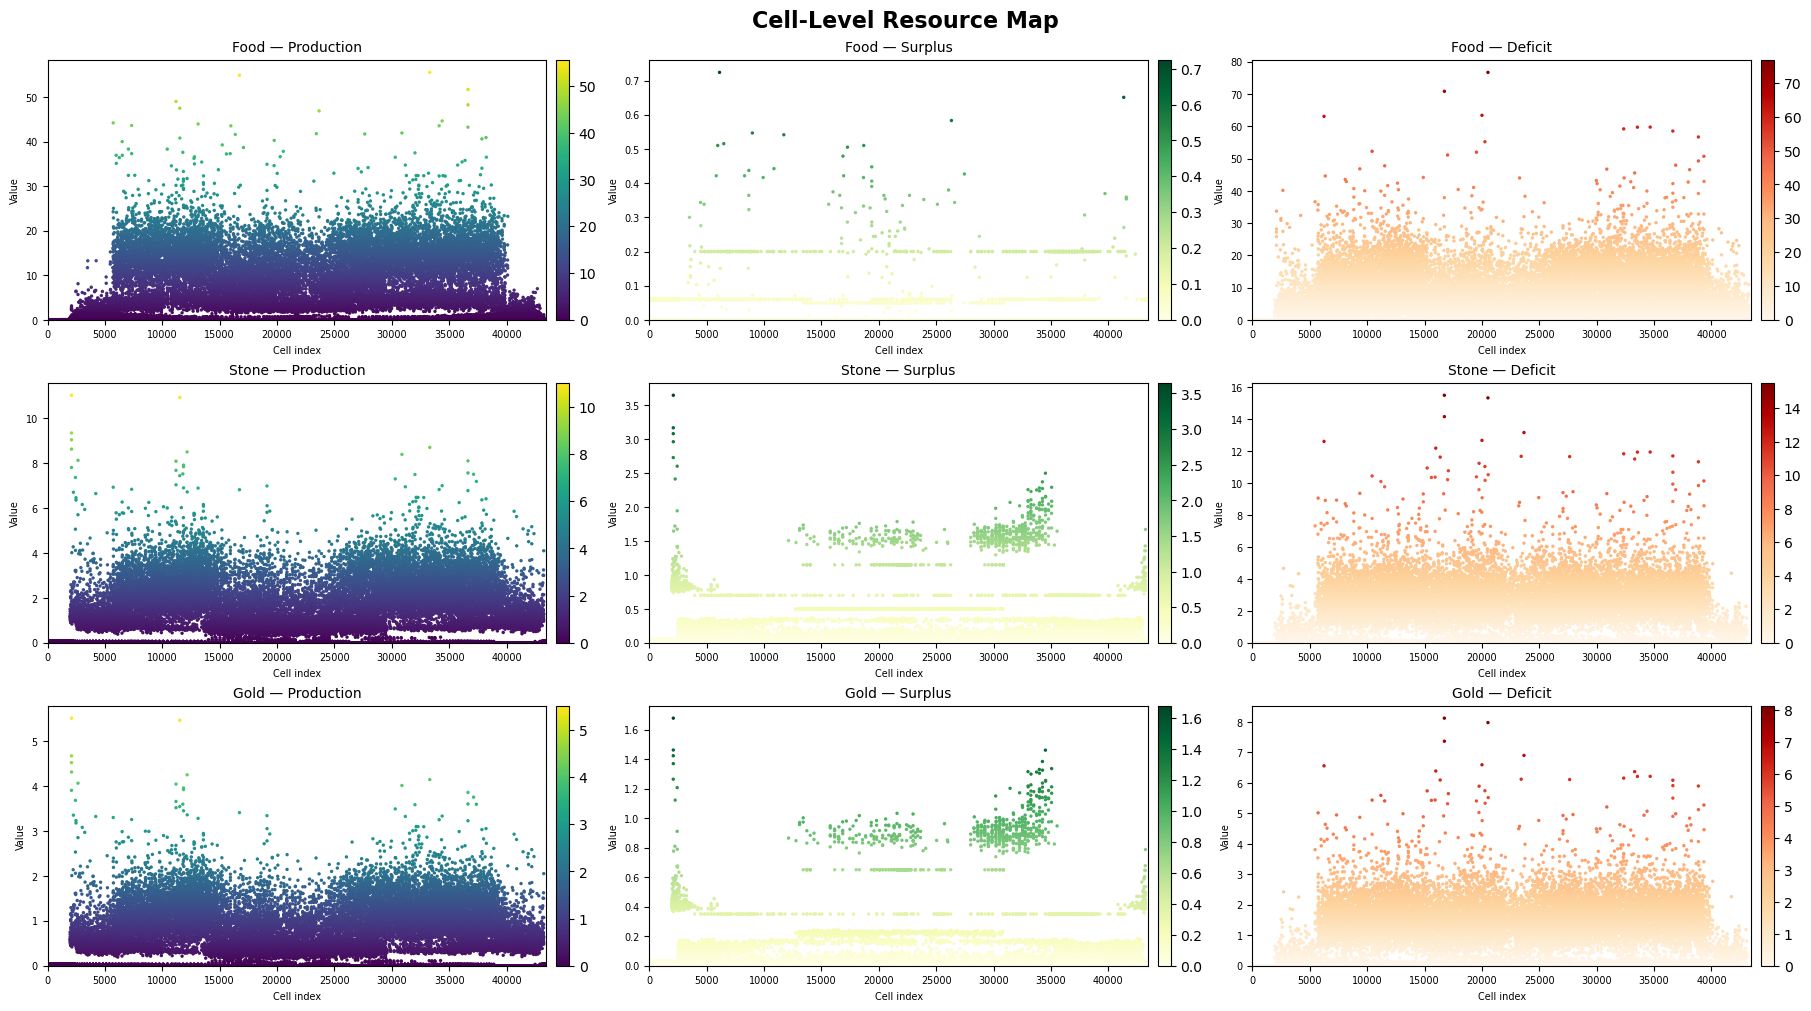

Saved: cell_resource_map.png


In [114]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_cell_resource_maps(cells, combined):
    """
    Plot 3x3 grid of subplots: rows = food/stone/gold, columns = production/surplus/deficit.
    Each cell is represented as a point at (cell_index, 0), coloured by resource value.
    """

    resources = ["food", "stone", "gold"]
    metrics   = ["production", "surplus", "deficit"]

    data_lookup = {
        "production": combined["production"],
        "surplus":    combined["surplus"],
        "deficit":    combined["deficit"],
    }

    cmaps = {
        "production": "viridis",
        "surplus":    "YlGn",
        "deficit":    "OrRd",
    }

    fig, axes = plt.subplots(
        nrows=3, ncols=3,
        figsize=(18, 10),
        constrained_layout=True,
    )
    fig.suptitle("Cell-Level Resource Map", fontsize=16, fontweight="bold")

    cell_ids = [c["i"] for c in cells]
    x        = np.arange(len(cell_ids))          # x axis = cell index position
    id_to_x  = {cid: i for i, cid in enumerate(cell_ids)}

    for row, resource in enumerate(resources):
        for col, metric in enumerate(metrics):
            ax     = axes[row][col]
            lookup = data_lookup[metric]

            values = np.array([
                lookup.get(cid, {}).get(resource, 0)
                for cid in cell_ids
            ], dtype=float)

            vmin = 0
            vmax = values.max() if values.max() > 0 else 1
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
            cmap = plt.get_cmap(cmaps[metric])

            sc = ax.scatter(x, values, c=values, cmap=cmap, norm=norm,
                            s=6, linewidths=0)

            ax.set_title(f"{resource.capitalize()} — {metric.capitalize()}", fontsize=10)
            ax.set_xlabel("Cell index", fontsize=7)
            ax.set_ylabel("Value", fontsize=7)
            ax.tick_params(labelsize=7)
            ax.set_xlim(-1, len(cell_ids))
            ax.set_ylim(bottom=0)

            plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)

    plt.savefig("cell_resource_map.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: cell_resource_map.png")


result = tick(data)
plot_cell_resource_maps(data.cells, result)


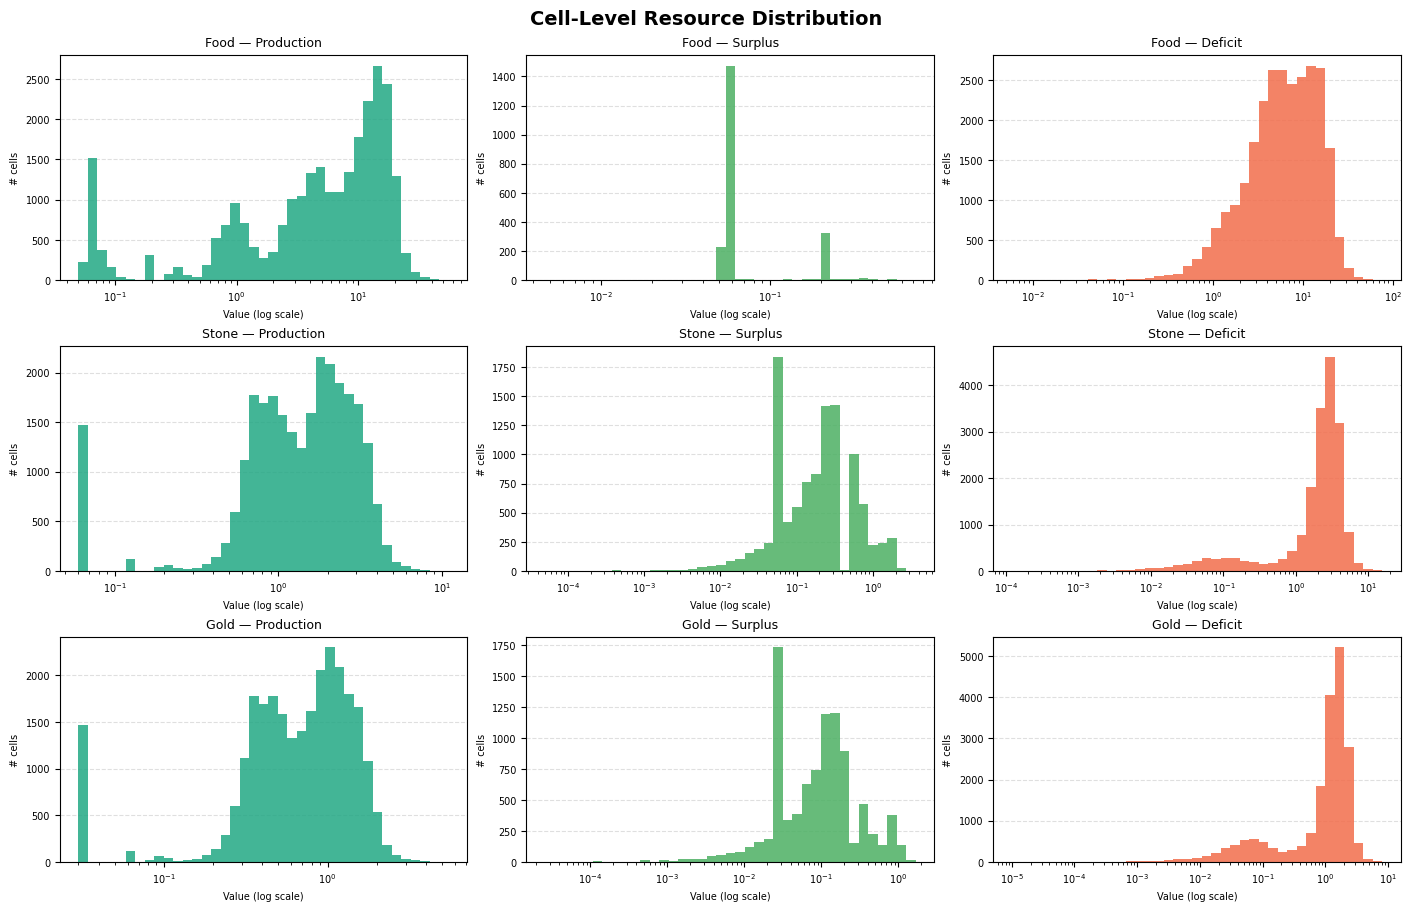

Saved: cell_resource_map.png


In [115]:
def plot_cell_resource_maps(cells, combined):
    """
    3x3 grid: rows = food/stone/gold, columns = production/surplus/deficit.
    Each subplot shows a histogram of per-cell values (log-scaled x-axis).
    """
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import numpy as np

    resources = ["food", "stone", "gold"]
    metrics   = ["production", "surplus", "deficit"]

    cmaps = {"production": "viridis", "surplus": "YlGn", "deficit": "OrRd"}
    data_lookup = {m: combined[m] for m in metrics}
    cell_ids = [c["i"] for c in cells]

    fig, axes = plt.subplots(
        nrows=3, ncols=3,
        figsize=(14, 9),
        constrained_layout=True,
    )
    fig.suptitle("Cell-Level Resource Distribution", fontsize=14, fontweight="bold")

    for row, resource in enumerate(resources):
        for col, metric in enumerate(metrics):
            ax     = axes[row][col]
            lookup = data_lookup[metric]

            values = np.array(
                [lookup.get(cid, {}).get(resource, 0) for cid in cell_ids],
                dtype=float,
            )
            nonzero = values[values > 0]

            if len(nonzero) == 0:
                ax.text(0.5, 0.5, "no data", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9)
            else:
                # Log-spaced bins handle the wide value range without giant canvases
                bins = np.logspace(np.log10(nonzero.min()), np.log10(nonzero.max()), 40)
                cmap  = plt.get_cmap(cmaps[metric])
                color = cmap(0.6)
                ax.hist(nonzero, bins=bins, color=color, edgecolor="none", alpha=0.85)
                ax.set_xscale("log")

            ax.set_title(f"{resource.capitalize()} — {metric.capitalize()}", fontsize=9)
            ax.set_xlabel("Value (log scale)", fontsize=7)
            ax.set_ylabel("# cells", fontsize=7)
            ax.tick_params(labelsize=7)
            ax.yaxis.grid(True, linestyle="--", alpha=0.4)
            ax.set_axisbelow(True)

    plt.savefig("cell_resource_map.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: cell_resource_map.png")
plot_cell_resource_maps(data.cells,result)

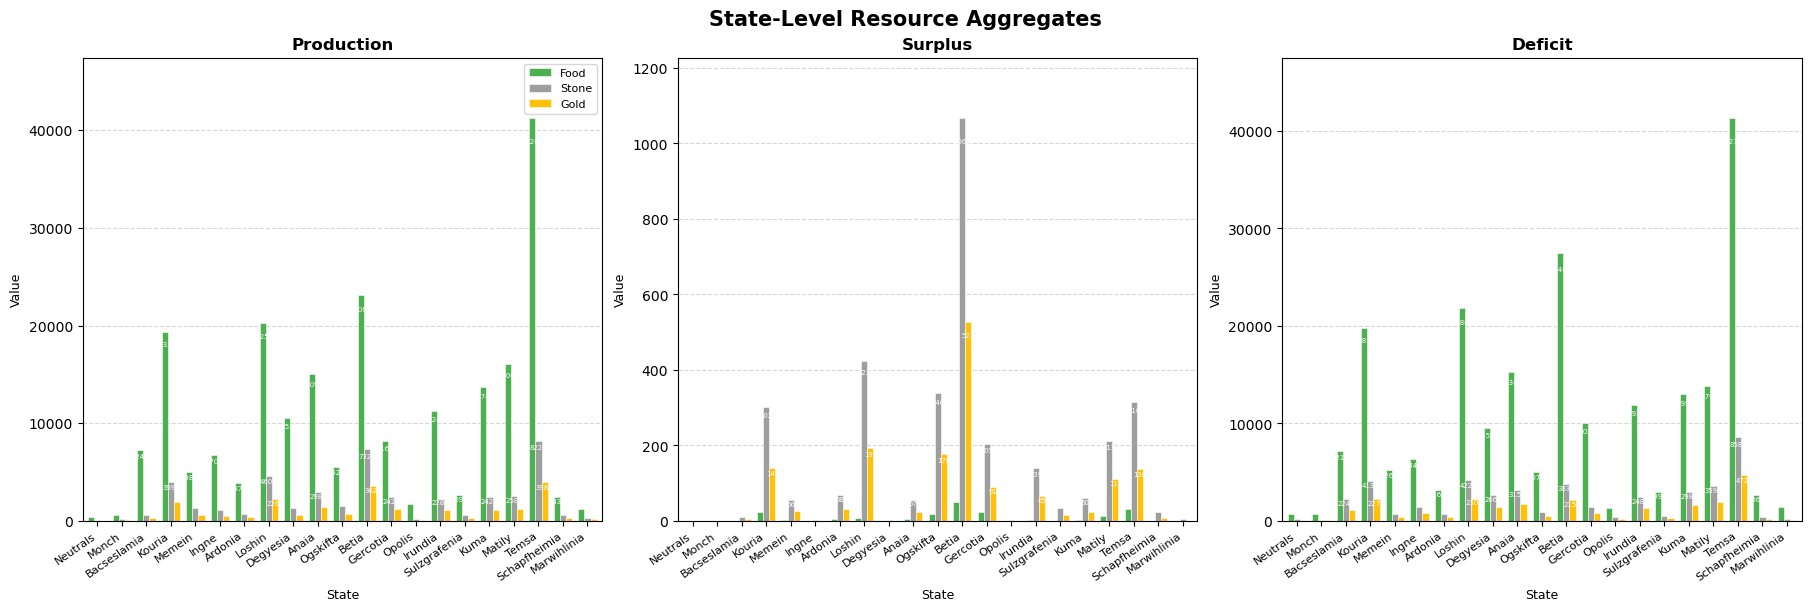

Saved: state_resource_aggregates.png


In [116]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


def aggregate_cells_to_states(cells, combined, states):
    resources = ["food", "stone", "gold"]
    cell_state = {c["i"]: c["state"] for c in cells}

    for metric in ["surplus", "deficit"]:
        state_totals = defaultdict(lambda: {r: 0.0 for r in resources})
        for cid, res_dict in combined[metric].items():
            sid = cell_state.get(cid)
            if sid is None:
                continue
            for resource in resources:
                state_totals[sid][resource] += res_dict.get(resource, 0)

        out = {}
        for state in states:
            out[state["name"]] = {
                r: state_totals[state["i"]][r] for r in resources
            }
        combined[f"state_{metric}"] = out

    return combined


def plot_state_resource_aggregates(states, combined):
    resources = ["food", "stone", "gold"]
    metrics   = ["production", "surplus", "deficit"]

    resource_colors = {
        "food":  "#4caf50",
        "stone": "#9e9e9e",
        "gold":  "#ffc107",
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    fig.suptitle("State-Level Resource Aggregates", fontsize=15, fontweight="bold")

    state_names = [s["name"] for s in states]
    x           = np.arange(len(state_names))
    bar_width   = 0.25
    offsets     = np.array([-bar_width, 0, bar_width])

    for col, metric in enumerate(metrics):
        ax      = axes[col]
        dataset = combined[f"state_{metric}"]

        ax.set_title(metric.capitalize(), fontsize=12, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(state_names, rotation=35, ha="right", fontsize=8)
        ax.set_ylabel("Value", fontsize=9)
        ax.set_xlabel("State", fontsize=9)
        ax.set_xlim(-0.6, len(state_names) - 0.4)
        ax.yaxis.grid(True, linestyle="--", alpha=0.5)
        ax.set_axisbelow(True)

        all_values = []
        for resource in resources:
            all_values.extend([dataset.get(s["name"], {}).get(resource, 0) for s in states])
        max_val = max(all_values) if all_values else 1
        ax.set_ylim(0, max_val * 1.15)

        for r_idx, resource in enumerate(resources):
            values = [dataset.get(s["name"], {}).get(resource, 0) for s in states]

            bars = ax.bar(
                x + offsets[r_idx],
                values,
                width=bar_width,
                color=resource_colors[resource],
                label=resource.capitalize(),
                edgecolor="white",
                linewidth=0.4,
            )

            for bar, val in zip(bars, values):
                if val > max_val * 0.05:  # only label bars taller than 5% of max
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() * 0.95,
                        f"{val:.0f}",
                        ha="center", va="top",
                        fontsize=5, color="white",
                    )

        if col == 0:
            ax.legend(fontsize=8, loc="upper right")

    plt.savefig("state_resource_aggregates.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: state_resource_aggregates.png")


# --- Call site ---
result = tick(data)
result = aggregate_cells_to_states(data.cells, result, data.states)
plot_state_resource_aggregates(data.states, result)

In [117]:
def report_deficits(cells, states, combined):
    resources = ["food", "stone", "gold"]
    
    # --- Cell-level deficits ---
    cell_state = {c["i"]: c["state"] for c in cells}
    state_id_to_name = {s["i"]: s["name"] for s in states}

    print("=== CELL-LEVEL DEFICITS ===")
    any_cell_deficit = False
    for cid, res_dict in combined["deficit"].items():
        deficits = {r: v for r, v in res_dict.items() if v > 0}
        if deficits:
            any_cell_deficit = True
            sid = cell_state.get(cid)
            state_name = state_id_to_name.get(sid, "unknown")
            deficit_str = ", ".join(f"{r}: {v:.2f}" for r, v in deficits.items())
            print(f"  Cell {cid:>5} ({state_name}): {deficit_str}")
    if not any_cell_deficit:
        print("  No cell deficits.")

    


report_deficits(data.cells, data.states, result)

=== CELL-LEVEL DEFICITS ===
  Cell  1965 (Gercotia): food: 2.80, stone: 0.56, gold: 0.29
  Cell  1966 (Gercotia): food: 2.49, stone: 0.50, gold: 0.26
  Cell  1967 (Gercotia): food: 6.21, stone: 1.24, gold: 0.65
  Cell  1968 (Gercotia): food: 1.40
  Cell  1969 (Gercotia): food: 2.43
  Cell  1970 (Gercotia): food: 0.92
  Cell  1971 (Gercotia): food: 1.72
  Cell  1972 (Gercotia): food: 1.41
  Cell  1973 (Gercotia): food: 1.22
  Cell  1976 (Gercotia): food: 1.18
  Cell  1977 (Gercotia): food: 2.09
  Cell  1982 (Gercotia): food: 5.02, stone: 1.00, gold: 0.52
  Cell  1999 (Gercotia): food: 2.28
  Cell  2000 (Gercotia): food: 0.88
  Cell  2001 (Gercotia): food: 0.73
  Cell  2002 (Gercotia): food: 2.03
  Cell  2003 (Gercotia): food: 0.64
  Cell  2004 (Gercotia): food: 4.99
  Cell  2005 (Gercotia): food: 4.22
  Cell  2011 (Temsa): food: 2.53, stone: 0.51, gold: 0.26
  Cell  2015 (Temsa): food: 1.76
  Cell  2016 (Temsa): food: 1.26
  Cell  2017 (Temsa): food: 1.78
  Cell  2018 (Temsa): food: 0.4

In [118]:

def report_deficits(cells, states, combined):
    # --- State-level deficits ---
    print("\n=== STATE-LEVEL DEFICITS ===")
    any_state_deficit = False
    for state_name, res_dict in combined["state_deficit"].items():
        deficits = {r: v for r, v in res_dict.items() if v > 0}
        if deficits:
            any_state_deficit = True
            deficit_str = ", ".join(f"{r}: {v:.2f}" for r, v in deficits.items())
            print(f"  {state_name}: {deficit_str}")
    if not any_state_deficit:
        print("  No state deficits.")
report_deficits(data.cells, data.states, result)

result = aggregate_cells_to_states(data.cells, result, data.states)
print("-"*180)



=== STATE-LEVEL DEFICITS ===
  Neutrals: food: 743.60, stone: 160.04, gold: 85.56
  Monch: food: 758.41, stone: 127.08, gold: 70.78
  Bacseslamia: food: 7211.39, stone: 2239.86, gold: 1177.27
  Kouria: food: 19818.95, stone: 4137.26, gold: 2270.88
  Memein: food: 5266.56, stone: 767.35, gold: 434.97
  Ingne: food: 6346.79, stone: 1480.54, gold: 812.15
  Ardonia: food: 3161.66, stone: 719.63, gold: 390.30
  Loshin: food: 21807.16, stone: 4225.88, gold: 2305.80
  Degyesia: food: 9552.17, stone: 2665.67, gold: 1432.32
  Anaia: food: 15308.87, stone: 3154.91, gold: 1752.09
  Ogskifta: food: 5069.82, stone: 938.34, gold: 517.69
  Betia: food: 27469.21, stone: 3838.67, gold: 2150.29
  Gercotia: food: 10035.72, stone: 1411.90, gold: 792.46
  Opolis: food: 1334.92, stone: 440.43, gold: 232.30
  Irundia: food: 11922.46, stone: 2483.34, gold: 1352.41
  Sulzgrafenia: food: 2999.39, stone: 517.44, gold: 288.52
  Kuma: food: 12992.50, stone: 2985.41, gold: 1628.11
  Matily: food: 13791.15, stone: 

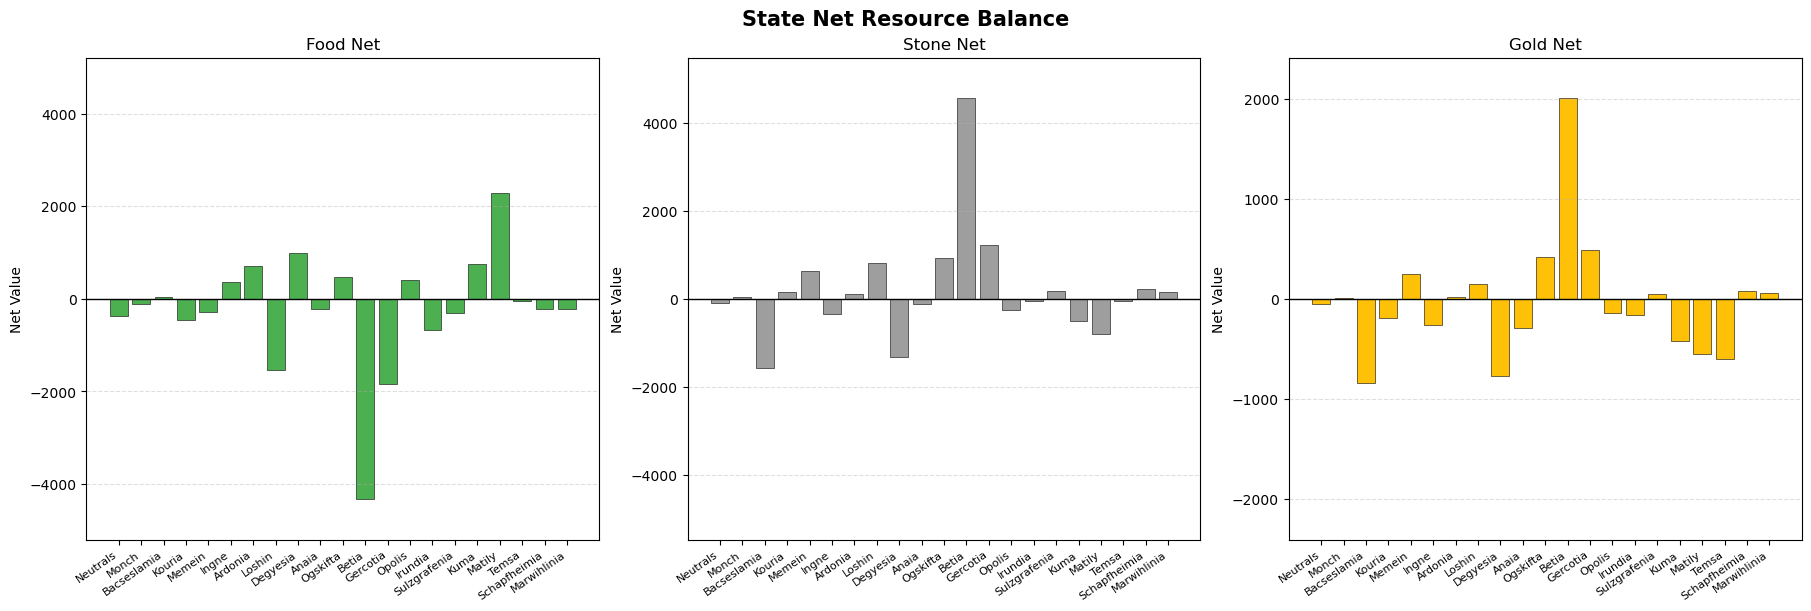

Saved: state_net_by_resource.png


In [119]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


def plot_state_net_by_resource(states, combined):
    resources = ["food", "stone", "gold"]

    state_names = [s["name"] for s in states]

    prod = combined.get("state_production", {})
    surp = combined.get("state_surplus", {})
    defi = combined.get("state_deficit", {})

    net = {r: [] for r in resources}

    for s in states:
        name = s["name"]

        for r in resources:
            p = prod.get(name, {}).get(r, 0)
            s_ = surp.get(name, {}).get(r, 0)
            d = defi.get(name, {}).get(r, 0)

            net[r].append(p + s_ - d)

    x = np.arange(len(state_names))

    colors = {
        "food":  "#4caf50",
        "stone": "#9e9e9e",
        "gold":  "#ffc107",
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    fig.suptitle("State Net Resource Balance", fontsize=15, fontweight="bold")

    for i, r in enumerate(resources):
        ax = axes[i]

        ax.bar(x, net[r], color=colors[r], edgecolor="black", linewidth=0.4)

        ax.axhline(0, color="black", linewidth=1)
        ax.set_title(f"{r.capitalize()} Net")
        ax.set_xticks(x)
        ax.set_xticklabels(state_names, rotation=35, ha="right", fontsize=8)
        ax.set_ylabel("Net Value")
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        # consistent scale per subplot (optional but helpful)
        max_val = max(abs(min(net[r])), abs(max(net[r])), 1)
        ax.set_ylim(-max_val * 1.2, max_val * 1.2)

    plt.savefig("state_net_by_resource.png", dpi=120, bbox_inches="tight")
    plt.show()

    print("Saved: state_net_by_resource.png")


# call
plot_state_net_by_resource(data.states, result)